# Evaluation of the explicit-input `Nescience` class

This notebook demonstrates the simplified four-component `Nescience` class.

The new class evaluates nescience from three explicit model artifacts:

```python
subset       # selected feature indices or binary feature mask
predictions  # model predictions
model_string # explicit model description
```

It then computes:

\[
\mathcal{N} = A(D, \Omega, I, S),
\]

where:

- \(D\) is **feature deficiency**: target information not explained by the selected features;
- \(\Omega\) is **feature surplus**: information in the selected features not explained by the target;
- \(I\) is **inaccuracy**: mismatch between target values and predictions;
- \(S\) is **surfeit**: redundancy or excess in the model description.

This design deliberately keeps model inspection and model serialization outside the `Nescience` class.


## 1. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits, load_breast_cancer, make_classification
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score

from nescience.nescience import Nescience, nescience_score, nescience_components

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 5)

## 2. Helper functions

The new `Nescience` class does not inspect models. The following helpers are notebook-side utilities that extract the three explicit artifacts needed by the metric.

In production code, these helpers would normally live in a separate serialization or inspection module.


In [2]:
def feature_subset_from_model(model, n_features, *, tol=1e-12):
    """Return a sorted list of feature indices used by a fitted model."""
    if isinstance(model, DecisionTreeClassifier):
        features = model.tree_.feature
        return sorted(int(j) for j in np.unique(features[features >= 0]))

    if isinstance(model, RandomForestClassifier):
        used = set()
        for estimator in model.estimators_:
            features = estimator.tree_.feature
            used.update(int(j) for j in np.unique(features[features >= 0]))
        return sorted(used)

    if isinstance(model, MLPClassifier):
        first_layer = model.coefs_[0]
        used = np.where(np.any(np.abs(first_layer) > tol, axis=1))[0]
        return sorted(int(j) for j in used)

    if isinstance(model, DummyClassifier):
        return []

    # Conservative fallback: assume the model may use every feature.
    return list(range(n_features))


def decision_tree_to_string(model, feature_names=None):
    """Serialize a fitted decision tree into a readable text description."""
    if feature_names is None:
        feature_names = [f"x{i}" for i in range(model.n_features_in_)]
    return export_text(model, feature_names=feature_names)


def random_forest_to_string(model, feature_names=None, *, max_trees=10):
    """Serialize the first trees of a fitted random forest."""
    lines = [
        f"RandomForestClassifier(n_estimators={len(model.estimators_)})",
        f"Showing first {min(max_trees, len(model.estimators_))} trees",
    ]

    for i, estimator in enumerate(model.estimators_[:max_trees]):
        lines.append(f"\n# Tree {i}")
        lines.append(decision_tree_to_string(estimator, feature_names=feature_names))

    return "\n".join(lines)


def mlp_to_string(model):
    """Serialize an MLP by recording its architecture, weights, and biases."""
    lines = ["MLPClassifier"]
    lines.append(f"hidden_layer_sizes={model.hidden_layer_sizes}")
    lines.append(f"activation={model.activation}")
    lines.append(f"solver={model.solver}")

    for layer_index, weights in enumerate(model.coefs_):
        lines.append(
            f"weights_layer_{layer_index}="
            f"{np.array2string(weights, precision=4, separator=',')}"
        )

    for layer_index, biases in enumerate(model.intercepts_):
        lines.append(
            f"biases_layer_{layer_index}="
            f"{np.array2string(biases, precision=4, separator=',')}"
        )

    return "\n".join(lines)


def dummy_to_string(model):
    """Serialize a fitted dummy classifier."""
    return (
        "DummyClassifier\n"
        f"strategy={model.strategy}\n"
        f"classes={model.classes_.tolist()}\n"
        f"class_prior={np.array2string(model.class_prior_, precision=4, separator=',')}"
    )


def model_to_string(model, feature_names=None):
    """Serialize supported demo models outside the Nescience class."""
    if isinstance(model, DecisionTreeClassifier):
        return decision_tree_to_string(model, feature_names=feature_names)
    if isinstance(model, RandomForestClassifier):
        return random_forest_to_string(model, feature_names=feature_names)
    if isinstance(model, MLPClassifier):
        return mlp_to_string(model)
    if isinstance(model, DummyClassifier):
        return dummy_to_string(model)

    return repr(model)


def model_artifacts(model, X_eval, *, feature_names=None):
    """Return subset, predictions, and model_string for a fitted model."""
    return {
        "subset": feature_subset_from_model(model, X_eval.shape[1]),
        "predictions": model.predict(X_eval),
        "model_string": model_to_string(model, feature_names=feature_names),
    }


def component_row(name, model, nsc, X_eval, *, feature_names=None):
    """Return one row with nescience and its four components."""
    artifacts = model_artifacts(model, X_eval, feature_names=feature_names)
    components = nsc.components(**artifacts)
    nescience_value = nsc.aggregate_components(**components)

    return {
        "model": name,
        "nescience": nescience_value,
        **components,
        "n_features_in_use": len(artifacts["subset"]),
        "model_type": type(model).__name__,
        "description_length": len(artifacts["model_string"].encode("utf-8")),
    }


def explanation_row(name, model, nsc, X_eval, *, feature_names=None):
    """Return one row with the diagnostic explanation."""
    artifacts = model_artifacts(model, X_eval, feature_names=feature_names)
    explanation = nsc.explain(**artifacts)

    return {
        "model": name,
        "nescience": explanation["nescience"],
        "dominant_component": explanation["dominant_component"],
        "profile": explanation["profile"],
        "recommendation": explanation["recommendation"],
        "n_features_in_use": len(artifacts["subset"]),
        "model_type": type(model).__name__,
    }


def plot_components(df, title):
    """Plot the four nescience components for each model."""
    component_cols = ["deficiency", "surplus", "inaccuracy", "surfeit"]
    df.set_index("model")[component_cols].plot(kind="bar", figsize=(12, 5))
    plt.ylabel("Component value")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()


def plot_nescience(df, title):
    """Plot scalar nescience for each model."""
    df.set_index("model")["nescience"].plot(kind="bar", figsize=(10, 4))
    plt.ylabel("Nescience")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.show()


## 3. Basic example: a decision tree on the digits dataset

The new API requires us to provide the selected feature subset, the predictions, and the model description explicitly.


In [3]:
data = load_digits()
X = data.data
y = data.target
feature_names = [f"pixel_{i}" for i in range(X.shape[1])]

tree = DecisionTreeClassifier(max_depth=6, random_state=42)
tree.fit(X, y)

nsc = Nescience(
    X_type="numeric",
    y_type="categorical",
    aggregation="euclidean",
    n_bins="auto",
)

nsc.fit(X, y)

artifacts = model_artifacts(tree, X, feature_names=feature_names)

print("Selected feature subset:")
print(artifacts["subset"][:20], "..." if len(artifacts["subset"]) > 20 else "")

print("Training accuracy:")
print(accuracy_score(y, artifacts["predictions"]))

print("Model description preview:")
print(artifacts["model_string"][:1000])


Selected feature subset:
[2, 5, 6, 10, 12, 13, 18, 19, 21, 24, 27, 28, 29, 33, 34, 36, 37, 41, 42, 43] ...
Training accuracy:
0.8224819143016138
Model description preview:
|--- pixel_36 <= 0.50
|   |--- pixel_28 <= 2.50
|   |   |--- pixel_21 <= 0.50
|   |   |   |--- pixel_60 <= 13.50
|   |   |   |   |--- class: 5
|   |   |   |--- pixel_60 >  13.50
|   |   |   |   |--- pixel_41 <= 5.50
|   |   |   |   |   |--- pixel_44 <= 8.00
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- pixel_44 >  8.00
|   |   |   |   |   |   |--- class: 6
|   |   |   |   |--- pixel_41 >  5.50
|   |   |   |   |   |--- class: 4
|   |   |--- pixel_21 >  0.50
|   |   |   |--- pixel_44 <= 12.50
|   |   |   |   |--- pixel_62 <= 7.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- pixel_62 >  7.50
|   |   |   |   |   |--- class: 2
|   |   |   |--- pixel_44 >  12.50
|   |   |   |   |--- class: 4
|   |--- pixel_28 >  2.50
|   |   |--- pixel_21 <= 6.50
|   |   |   |--- pixel_42 <= 3.50
|   |   |   |   

The method `components()` returns the four underlying quantities.

In [4]:
components = nsc.components(**artifacts)
components


{'deficiency': 0.0,
 'surplus': 0.6927518055743368,
 'inaccuracy': 0.2729622093199616,
 'surfeit': 0.8941680261011419}

The method `nescience()` returns the aggregated scalar value.

In [5]:
nsc.nescience(**artifacts)


0.5817967623545508

The method `explain()` gives a higher-level diagnostic interpretation.

In [6]:
nsc.explain(**artifacts)


{'nescience': 0.5817967623545508,
 'aggregation': 'euclidean',
 'weights': {'deficiency': np.float64(1.0),
  'surplus': np.float64(1.0),
  'inaccuracy': np.float64(1.0),
  'surfeit': np.float64(1.0)},
 'components': {'deficiency': 0.0,
  'surplus': 0.6927518055743368,
  'inaccuracy': 0.2729622093199616,
  'surfeit': 0.8941680261011419},
 'dominant_component': 'surfeit',
 'profile': 'over_fed_model',
 'profile_explanation': 'The selected features contain substantial information that is not explained by the target.',
 'recommendation': 'Dominant source of nescience: surfeit (0.8942). Simplify the model description: prune, regularize, reduce model size, choose a more compact model family, or remove unnecessary parameters and rules.'}

The functional helpers are useful when a full estimator object is not needed.

In [7]:
nescience_components(
    X,
    y,
    X_type="numeric",
    y_type="categorical",
    **artifacts,
)


{'deficiency': 0.0,
 'surplus': 0.6927518055743368,
 'inaccuracy': 0.2729622093199616,
 'surfeit': 0.8941680261011419}

In [8]:
nescience_score(
    X,
    y,
    X_type="numeric",
    y_type="categorical",
    **artifacts,
)


0.5817967623545508

## 4. Comparing several model classes

The scalar nescience score is useful for ranking models. The four components are useful for understanding *why* the models differ.


In [9]:
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = list(data.feature_names)

models = {
    "dummy": DummyClassifier(strategy="most_frequent"),
    "small_tree": DecisionTreeClassifier(max_depth=2, random_state=42),
    "medium_tree": DecisionTreeClassifier(max_depth=4, random_state=42),
    "deep_tree": DecisionTreeClassifier(random_state=42),
    "small_mlp": MLPClassifier(hidden_layer_sizes=(8,), max_iter=1000, random_state=42),
}

for model in models.values():
    model.fit(X, y)

nsc = Nescience(
    X_type="numeric",
    y_type="categorical",
    aggregation="euclidean",
    n_bins="auto",
)

nsc.fit(X, y)

comparison = pd.DataFrame(
    [
        component_row(name, model, nsc, X, feature_names=feature_names)
        for name, model in models.items()
    ]
).sort_values("nescience")

comparison


,model,nescience,deficiency,surplus,inaccuracy,surfeit,n_features_in_use,model_type,description_length
1,small_tree,0.564495,0.033023,0.888942,0.332169,0.610714,3,DecisionTreeClassifier,280
2,medium_tree,0.598463,0.000000,0.895833,0.133032,0.782570,10,DecisionTreeClassifier,1136
3,deep_tree,0.615952,0.000000,0.895913,0.000000,0.845535,13,DecisionTreeClassifier,2486
4,small_mlp,0.634993,0.000000,0.895913,0.319612,0.841460,30,MLPClassifier,3419
0,dummy,0.708076,1.000000,0.000000,1.000000,0.074074,0,DummyClassifier,81


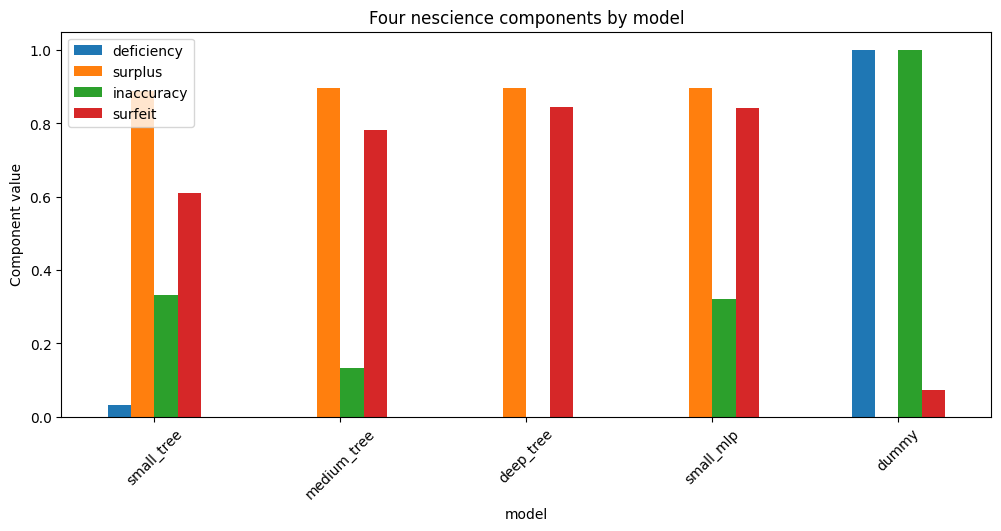

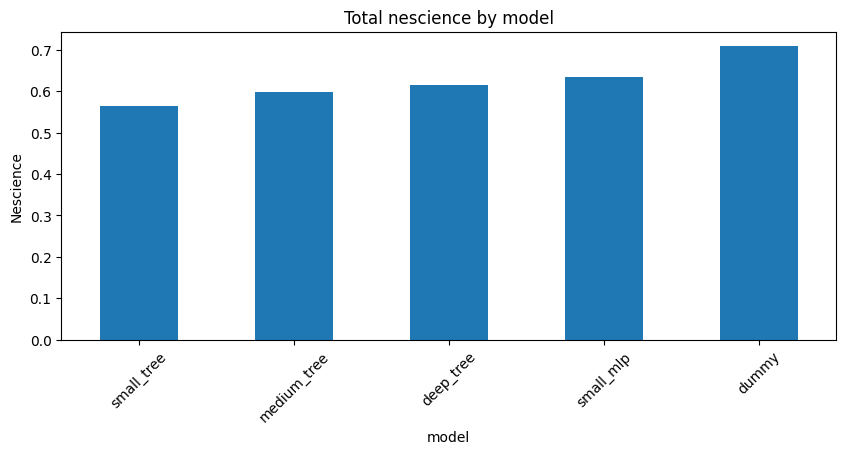

In [10]:
plot_components(comparison, "Four nescience components by model")
plot_nescience(comparison, "Total nescience by model")


In [11]:
explanations = pd.DataFrame(
    [
        explanation_row(name, model, nsc, X, feature_names=feature_names)
        for name, model in models.items()
    ]
)

explanations.sort_values("nescience")


,model,nescience,dominant_component,profile,recommendation,n_features_in_use,model_type
1,small_tree,0.564495,surplus,over_fed_model,Dominant source of nescience: surplus (0.8889)...,3,DecisionTreeClassifier
2,medium_tree,0.598463,surplus,over_fed_model,Dominant source of nescience: surplus (0.8958)...,10,DecisionTreeClassifier
3,deep_tree,0.615952,surplus,over_fed_model,Dominant source of nescience: surplus (0.8959)...,13,DecisionTreeClassifier
4,small_mlp,0.634993,surplus,over_fed_model,Dominant source of nescience: surplus (0.8959)...,30,MLPClassifier
0,dummy,0.708076,deficiency,under_informed_model,Dominant source of nescience: deficiency (1.00...,0,DummyClassifier


Two models with similar total nescience may have different causes: one may be inaccurate, another may be over-complex, and another may use excessive input information.


## 5. Evolution of nescience with decision-tree depth

This experiment shows how the four components change as a decision tree becomes more expressive.


In [12]:
records = []

for depth in range(1, 13):
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X, y)

    artifacts = model_artifacts(tree, X, feature_names=feature_names)
    components = nsc.components(**artifacts)

    cv_error = 1.0 - cross_val_score(
        tree,
        X,
        y,
        cv=5,
        scoring="accuracy",
    ).mean()

    records.append(
        {
            "max_depth": depth,
            "accuracy": accuracy_score(y, artifacts["predictions"]),
            "nescience": nsc.aggregate_components(**components),
            **components,
            "cv_error": cv_error,
            "n_features_in_use": len(artifacts["subset"]),
            "description_length": len(artifacts["model_string"].encode("utf-8")),
        }
    )

depth_results = pd.DataFrame(records)
depth_results


,max_depth,accuracy,nescience,deficiency,surplus,inaccuracy,surfeit,cv_error,n_features_in_use,description_length
0,1,0.922671,0.521667,0.325756,0.808848,0.410117,0.400000,0.100155,1,90
1,2,0.942004,0.564495,0.033023,0.888942,0.332169,0.610714,0.072039,3,280
2,3,0.978910,0.585134,0.000000,0.895713,0.154776,0.737069,0.080888,7,696
3,4,0.982425,0.598463,0.000000,0.895833,0.133032,0.782570,0.079118,10,1136
4,5,0.994728,0.609336,0.000000,0.895913,0.046178,0.824844,0.080857,13,1924
5,6,0.998243,0.612144,0.000000,0.895913,0.018309,0.834197,0.079118,15,2316
6,7,1.000000,0.615952,0.000000,0.895913,0.000000,0.845535,0.080888,13,2486
7,8,1.000000,0.615952,0.000000,0.895913,0.000000,0.845535,0.084412,13,2486
8,9,1.000000,0.615952,0.000000,0.895913,0.000000,0.845535,0.082658,13,2486
9,10,1.000000,0.615952,0.000000,0.895913,0.000000,0.845535,0.082658,13,2486


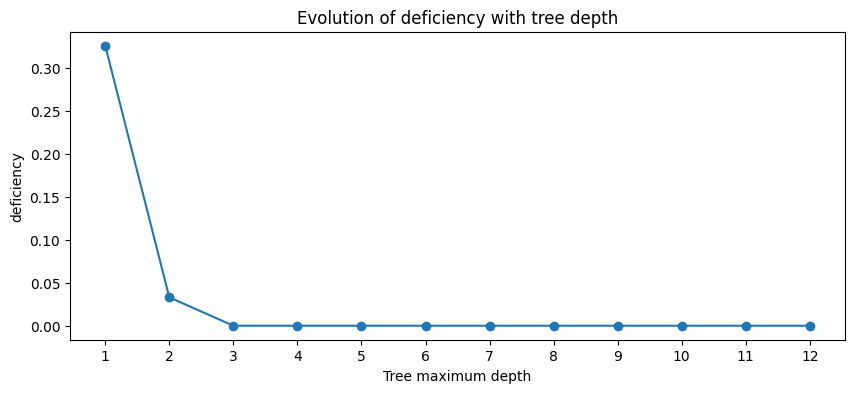

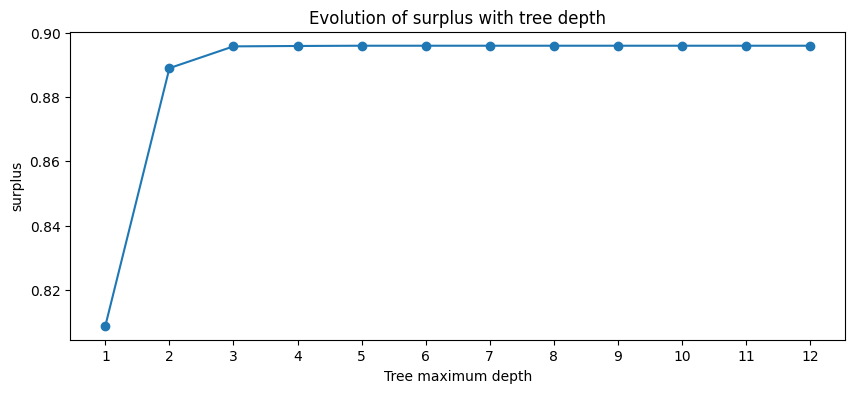

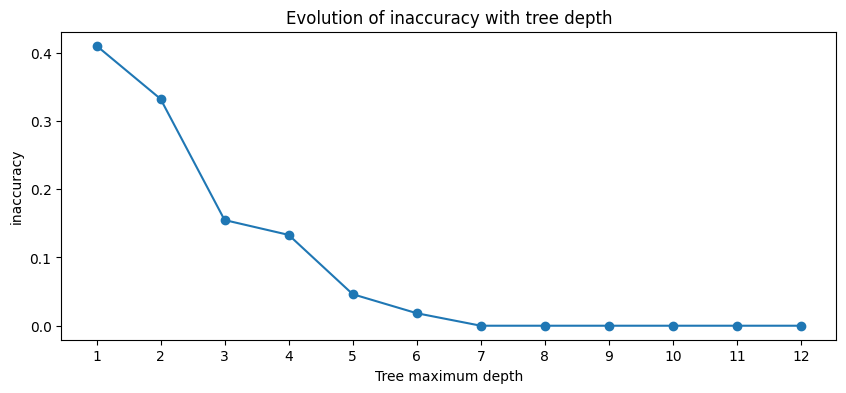

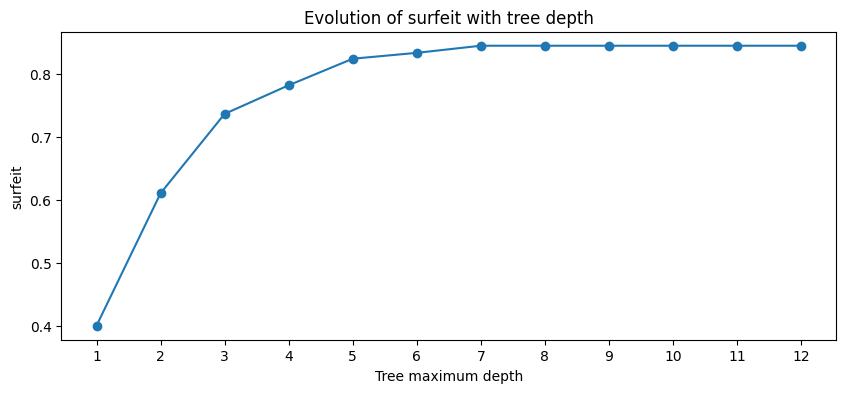

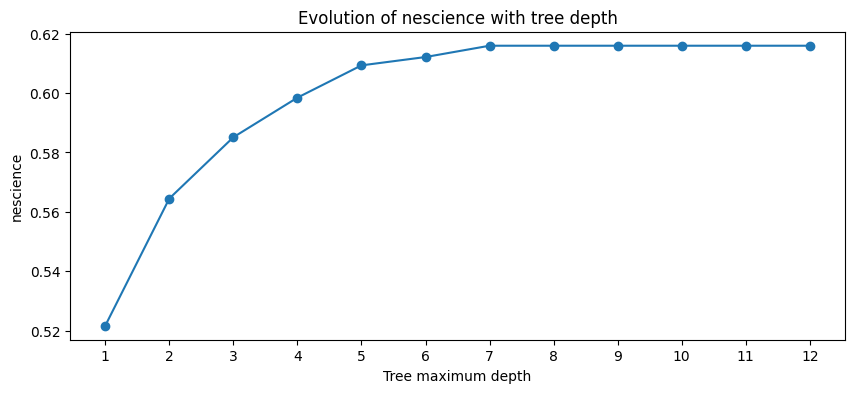

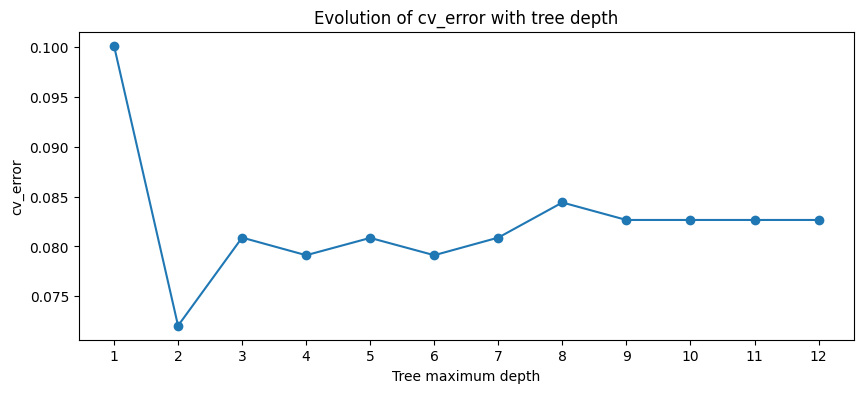

In [13]:
for column in ["deficiency", "surplus", "inaccuracy", "surfeit", "nescience", "cv_error"]:
    plt.figure(figsize=(10, 4))
    plt.plot(depth_results["max_depth"], depth_results[column], marker="o")
    plt.xlabel("Tree maximum depth")
    plt.ylabel(column)
    plt.title(f"Evolution of {column} with tree depth")
    plt.xticks(depth_results["max_depth"])
    plt.show()


In [14]:
best_by_nescience = depth_results.loc[depth_results["nescience"].idxmin()]
best_by_cv = depth_results.loc[depth_results["cv_error"].idxmin()]

print("Best depth by nescience:")
print(best_by_nescience)

print("Best depth by cross-validation error:")
print(best_by_cv)


Best depth by nescience:
max_depth              1.000000
accuracy               0.922671
nescience              0.521667
deficiency             0.325756
surplus                0.808848
inaccuracy             0.410117
surfeit                0.400000
cv_error               0.100155
n_features_in_use      1.000000
description_length    90.000000
Name: 0, dtype: float64
Best depth by cross-validation error:
max_depth               2.000000
accuracy                0.942004
nescience               0.564495
deficiency              0.033023
surplus                 0.888942
inaccuracy              0.332169
surfeit                 0.610714
cv_error                0.072039
n_features_in_use       3.000000
description_length    280.000000
Name: 1, dtype: float64


Cross-validation is primarily concerned with predictive performance. Nescience also considers feature deficiency, feature surplus, and model-description surfeit.


## 6. Demonstrating input surplus with irrelevant noise features

We create a dataset with informative features and then add many irrelevant noise features. A model that uses many irrelevant features may keep low inaccuracy, while its surplus component increases.


In [15]:
X_base, y_base = make_classification(
    n_samples=1000,
    n_features=8,
    n_informative=4,
    n_redundant=0,
    n_repeated=0,
    n_classes=2,
    n_clusters_per_class=1,
    class_sep=1.5,
    flip_y=0.0,
    random_state=42,
)

rng = np.random.default_rng(42)
noise = rng.normal(size=(X_base.shape[0], 32))

X_clean = X_base
X_noisy = np.hstack([X_base, noise])

clean_forest = RandomForestClassifier(
    n_estimators=50,
    max_depth=None,
    random_state=42,
)

noisy_forest = RandomForestClassifier(
    n_estimators=50,
    max_depth=None,
    random_state=42,
)

clean_forest.fit(X_clean, y_base)
noisy_forest.fit(X_noisy, y_base)

nsc_clean = Nescience(X_type="numeric", y_type="categorical", n_bins="auto").fit(
    X_clean,
    y_base,
)
nsc_noisy = Nescience(X_type="numeric", y_type="categorical", n_bins="auto").fit(
    X_noisy,
    y_base,
)

clean_names = [f"base_{i}" for i in range(X_clean.shape[1])]
noisy_names = [f"feature_{i}" for i in range(X_noisy.shape[1])]

noise_comparison = pd.DataFrame(
    [
        component_row("clean_forest", clean_forest, nsc_clean, X_clean, feature_names=clean_names),
        component_row("noisy_forest", noisy_forest, nsc_noisy, X_noisy, feature_names=noisy_names),
    ]
)

noise_comparison


,model,nescience,deficiency,surplus,inaccuracy,surfeit,n_features_in_use,model_type,description_length
0,clean_forest,0.665002,0.0,0.899657,0.0,0.979555,8,RandomForestClassifier,48911
1,noisy_forest,0.667560,0.0,0.899657,0.0,0.986489,40,RandomForestClassifier,74015


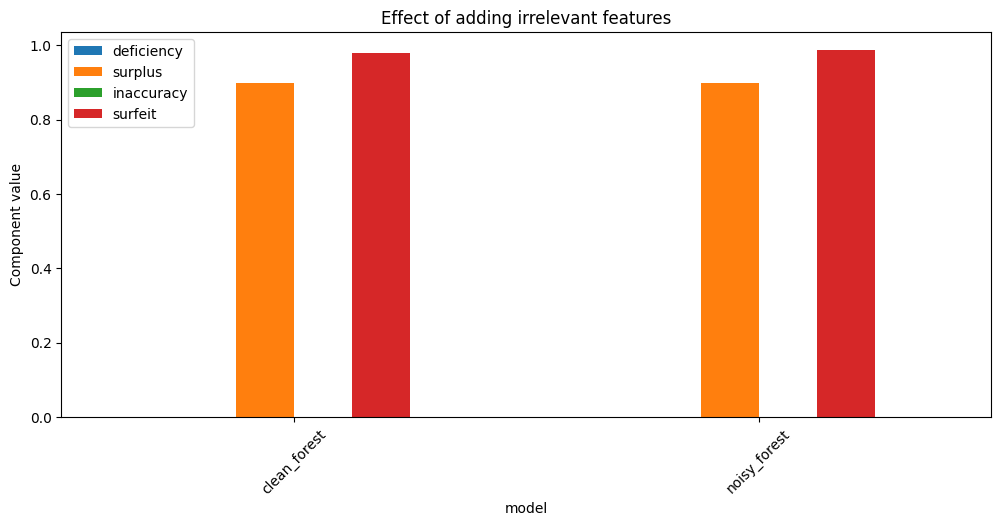

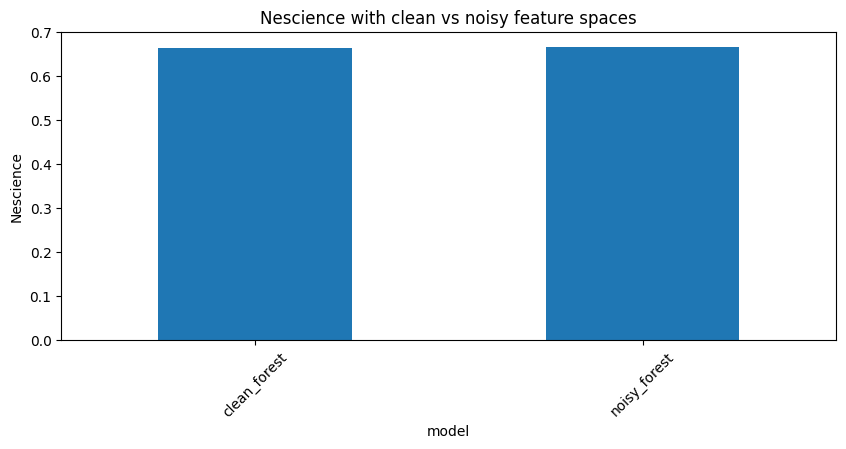

In [16]:
plot_components(noise_comparison, "Effect of adding irrelevant features")
plot_nescience(noise_comparison, "Nescience with clean vs noisy feature spaces")


In [17]:
pd.DataFrame(
    [
        explanation_row("clean_forest", clean_forest, nsc_clean, X_clean, feature_names=clean_names),
        explanation_row("noisy_forest", noisy_forest, nsc_noisy, X_noisy, feature_names=noisy_names),
    ]
)


,model,nescience,dominant_component,profile,recommendation,n_features_in_use,model_type
0,clean_forest,0.665002,surfeit,over_fed_model,Dominant source of nescience: surfeit (0.9796)...,8,RandomForestClassifier
1,noisy_forest,0.667560,surfeit,over_fed_model,Dominant source of nescience: surfeit (0.9865)...,40,RandomForestClassifier


The purpose of this experiment is not that every noisy feature is necessarily used by every model. Rather, it shows the kind of situation where the surplus component becomes important: the representation available to the model may contain information that is not explained by the target.


## 7. Demonstrating over-complexity through surfeit

Here we compare trees of increasing depth. A deeper tree may reduce inaccuracy, but it may also increase model surfeit.


In [18]:
complexity_records = []

for depth in [1, 2, 3, 4, 6, 8, None]:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X, y)

    artifacts = model_artifacts(tree, X, feature_names=feature_names)
    components = nsc.components(**artifacts)

    complexity_records.append(
        {
            "model": f"depth_{depth}",
            "max_depth": depth,
            "accuracy": accuracy_score(y, artifacts["predictions"]),
            "nescience": nsc.aggregate_components(**components),
            **components,
            "n_features_in_use": len(artifacts["subset"]),
            "description_length": len(artifacts["model_string"].encode("utf-8")),
        }
    )

complexity_results = pd.DataFrame(complexity_records)
complexity_results


,model,max_depth,accuracy,nescience,deficiency,surplus,inaccuracy,surfeit,n_features_in_use,description_length
0,depth_1,1.0,0.922671,0.521667,0.325756,0.808848,0.410117,0.400000,1,90
1,depth_2,2.0,0.942004,0.564495,0.033023,0.888942,0.332169,0.610714,3,280
2,depth_3,3.0,0.978910,0.585134,0.000000,0.895713,0.154776,0.737069,7,696
3,depth_4,4.0,0.982425,0.598463,0.000000,0.895833,0.133032,0.782570,10,1136
4,depth_6,6.0,0.998243,0.612144,0.000000,0.895913,0.018309,0.834197,15,2316
5,depth_8,8.0,1.000000,0.615952,0.000000,0.895913,0.000000,0.845535,13,2486
6,depth_None,NaN,1.000000,0.615952,0.000000,0.895913,0.000000,0.845535,13,2486


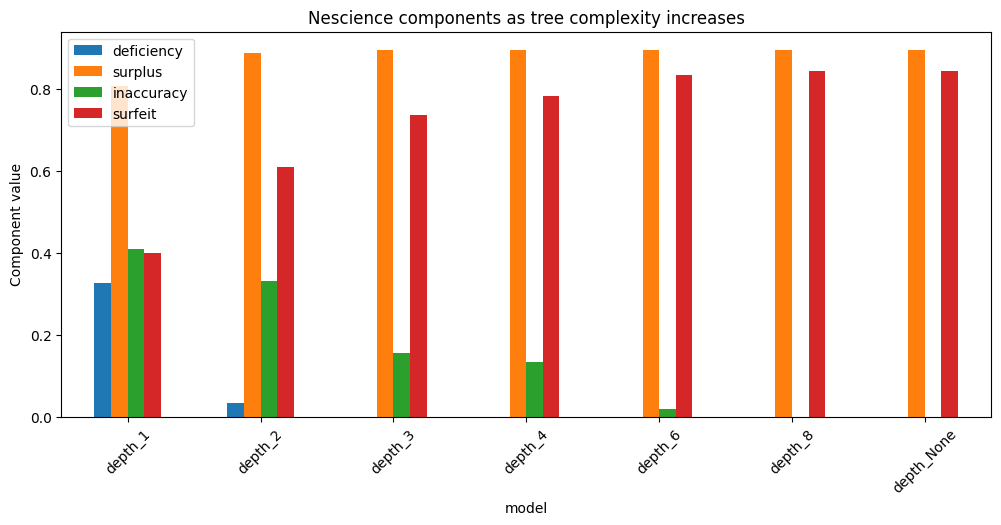

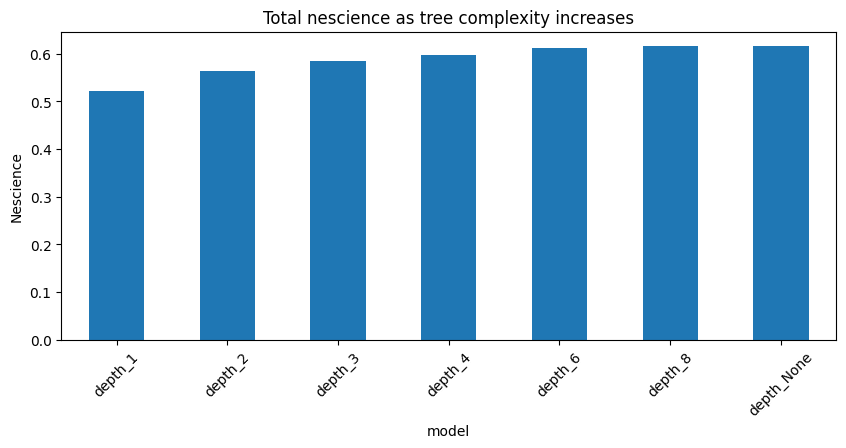

In [19]:
plot_components(complexity_results, "Nescience components as tree complexity increases")
plot_nescience(complexity_results, "Total nescience as tree complexity increases")


The surfeit component is useful because it can identify models that work well predictively but are unnecessarily complex as descriptions.


## 8. Aggregation choices

The aggregation function determines how much the four components may compensate for each other.

We compare three useful options:

- `euclidean`: balanced default that penalizes large components;
- `arithmetic`: simple weighted average;
- `maximum`: conservative, dominated by the worst active component.


In [20]:
aggregations = ["euclidean", "arithmetic", "maximum"]
aggregation_rows = []

for aggregation in aggregations:
    nsc_agg = Nescience(
        X_type="numeric",
        y_type="categorical",
        aggregation=aggregation,
        n_bins="auto",
    )
    nsc_agg.fit(X, y)

    for name, model in models.items():
        artifacts = model_artifacts(model, X, feature_names=feature_names)
        components = nsc_agg.components(**artifacts)
        aggregation_rows.append(
            {
                "aggregation": aggregation,
                "model": name,
                "nescience": nsc_agg.aggregate_components(**components),
                **components,
            }
        )

aggregation_results = pd.DataFrame(aggregation_rows)
aggregation_results


,aggregation,model,nescience,deficiency,surplus,inaccuracy,surfeit
0,euclidean,dummy,0.708076,1.000000,0.000000,1.000000,0.074074
1,euclidean,small_tree,0.564495,0.033023,0.888942,0.332169,0.610714
2,euclidean,medium_tree,0.598463,0.000000,0.895833,0.133032,0.782570
3,euclidean,deep_tree,0.615952,0.000000,0.895913,0.000000,0.845535
4,euclidean,small_mlp,0.634993,0.000000,0.895913,0.319612,0.841460
5,arithmetic,dummy,0.518519,1.000000,0.000000,1.000000,0.074074
6,arithmetic,small_tree,0.466212,0.033023,0.888942,0.332169,0.610714
7,arithmetic,medium_tree,0.452859,0.000000,0.895833,0.133032,0.782570
8,arithmetic,deep_tree,0.435362,0.000000,0.895913,0.000000,0.845535
9,arithmetic,small_mlp,0.514246,0.000000,0.895913,0.319612,0.841460


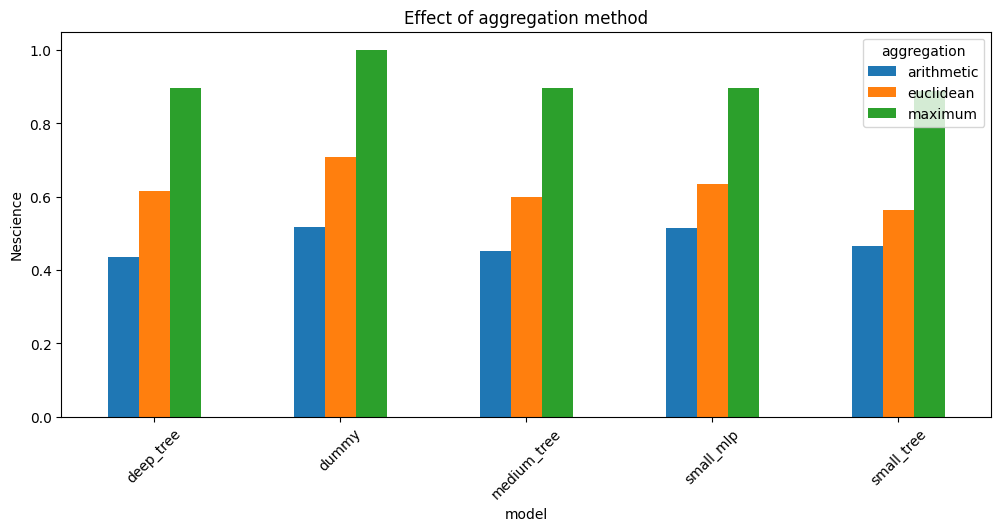

In [21]:
pivot = aggregation_results.pivot(
    index="model",
    columns="aggregation",
    values="nescience",
)

pivot.plot(kind="bar", figsize=(12, 5))
plt.ylabel("Nescience")
plt.title("Effect of aggregation method")
plt.xticks(rotation=45)
plt.show()


For model selection, `euclidean` is a balanced default. For conservative diagnosis, `maximum` may be preferable because a model is penalized by its worst component.


## 9. Weights: changing the practical objective

In some applications, predictive accuracy matters more. In others, compact and interpretable descriptions matter more.

Weights allow the same four components to be adapted to different practical objectives.


In [22]:
weight_settings = {
    "balanced": None,
    "accuracy_focused": {
        "deficiency": 1.0,
        "surplus": 1.0,
        "inaccuracy": 3.0,
        "surfeit": 1.0,
    },
    "simplicity_focused": {
        "deficiency": 1.0,
        "surplus": 2.0,
        "inaccuracy": 1.0,
        "surfeit": 3.0,
    },
}

weight_rows = []

for setting_name, weights in weight_settings.items():
    nsc_weighted = Nescience(
        X_type="numeric",
        y_type="categorical",
        aggregation="euclidean",
        weights=weights,
        n_bins="auto",
    )
    nsc_weighted.fit(X, y)

    for name, model in models.items():
        artifacts = model_artifacts(model, X, feature_names=feature_names)
        components = nsc_weighted.components(**artifacts)
        weight_rows.append(
            {
                "setting": setting_name,
                "model": name,
                "nescience": nsc_weighted.aggregate_components(**components),
            }
        )

weight_results = pd.DataFrame(weight_rows)
weight_results


,setting,model,nescience
0,balanced,dummy,0.708076
1,balanced,small_tree,0.564495
2,balanced,medium_tree,0.598463
3,balanced,deep_tree,0.615952
4,balanced,small_mlp,0.634993
5,accuracy_focused,dummy,0.817056
6,accuracy_focused,small_tree,0.499214
7,accuracy_focused,medium_tree,0.494642
8,accuracy_focused,deep_tree,0.502923
9,accuracy_focused,small_mlp,0.550329


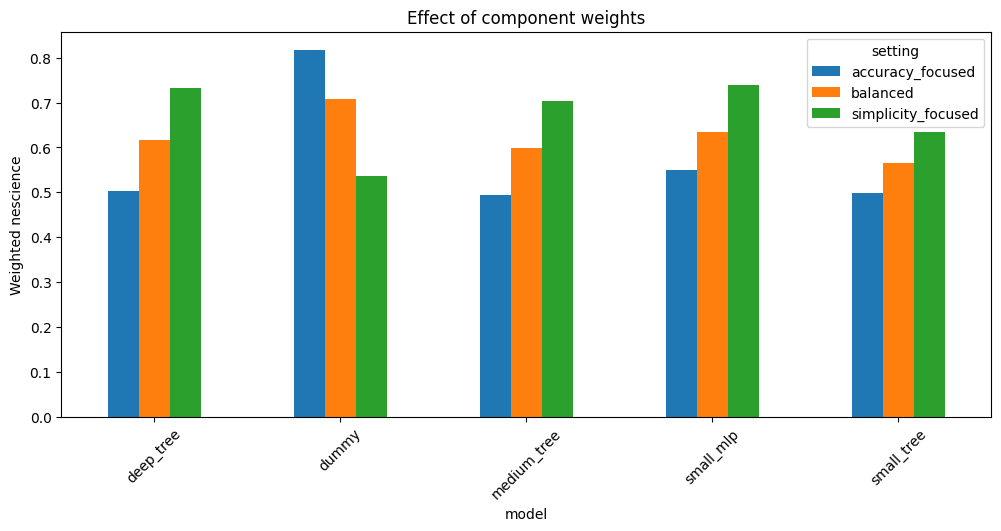

In [23]:
weight_pivot = weight_results.pivot(
    index="model",
    columns="setting",
    values="nescience",
)

weight_pivot.plot(kind="bar", figsize=(12, 5))
plt.ylabel("Weighted nescience")
plt.title("Effect of component weights")
plt.xticks(rotation=45)
plt.show()


This is useful because the Minimum Nescience Principle can be adapted to different practical contexts without changing the underlying four-component measurement.


## 10. Hyperparameter selection with an explicit nescience scorer

The simplified class is not a scikit-learn model inspector. Nevertheless, it can be used with `GridSearchCV` by defining an external scorer that extracts the explicit artifacts.


In [24]:
def explicit_nescience_scorer(estimator, X_val, y_val):
    """Return a higher-is-better score for GridSearchCV."""
    nsc_val = Nescience(
        X_type="numeric",
        y_type="categorical",
        aggregation="euclidean",
        n_bins="auto",
    )
    nsc_val.fit(X_val, y_val)

    artifacts = model_artifacts(estimator, X_val)
    return nsc_val.score(**artifacts)


In [25]:
data = load_digits()
X_digits = data.data
y_digits = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X_digits,
    y_digits,
    test_size=0.3,
    random_state=0,
    stratify=y_digits,
)

parameters = {
    "max_depth": [2, 4, 6, 8, None],
    "min_samples_leaf": [1, 5, 10],
}

grid_accuracy = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=parameters,
    cv=3,
    scoring="accuracy",
    n_jobs=1,
)

grid_nescience = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=parameters,
    cv=3,
    scoring=explicit_nescience_scorer,
    n_jobs=1,
)

grid_accuracy.fit(X_train, y_train)
grid_nescience.fit(X_train, y_train)

print("Best parameters by accuracy:")
print(grid_accuracy.best_params_)

print("\nBest parameters by nescience:")
print(grid_nescience.best_params_)


Best parameters by accuracy:
{'max_depth': None, 'min_samples_leaf': 1}

Best parameters by nescience:
{'max_depth': 6, 'min_samples_leaf': 5}


In [26]:
best_accuracy_model = grid_accuracy.best_estimator_
best_nescience_model = grid_nescience.best_estimator_

print("Accuracy-selected model test accuracy:")
print(accuracy_score(y_test, best_accuracy_model.predict(X_test)))

print("\nNescience-selected model test accuracy:")
print(accuracy_score(y_test, best_nescience_model.predict(X_test)))


Accuracy-selected model test accuracy:
0.85

Nescience-selected model test accuracy:
0.7722222222222223


In [27]:
nsc_test = Nescience(
    X_type="numeric",
    y_type="categorical",
    aggregation="euclidean",
    n_bins="auto",
).fit(X_test, y_test)

search_comparison = pd.DataFrame(
    [
        component_row("accuracy_selected", best_accuracy_model, nsc_test, X_test),
        component_row("nescience_selected", best_nescience_model, nsc_test, X_test),
    ]
)

search_comparison


,model,nescience,deficiency,surplus,inaccuracy,surfeit,n_features_in_use,model_type,description_length
0,accuracy_selected,0.571478,0.0,0.634042,0.266734,0.912794,44,DecisionTreeClassifier,16570
1,nescience_selected,0.566820,0.0,0.634042,0.336469,0.877451,24,DecisionTreeClassifier,3468


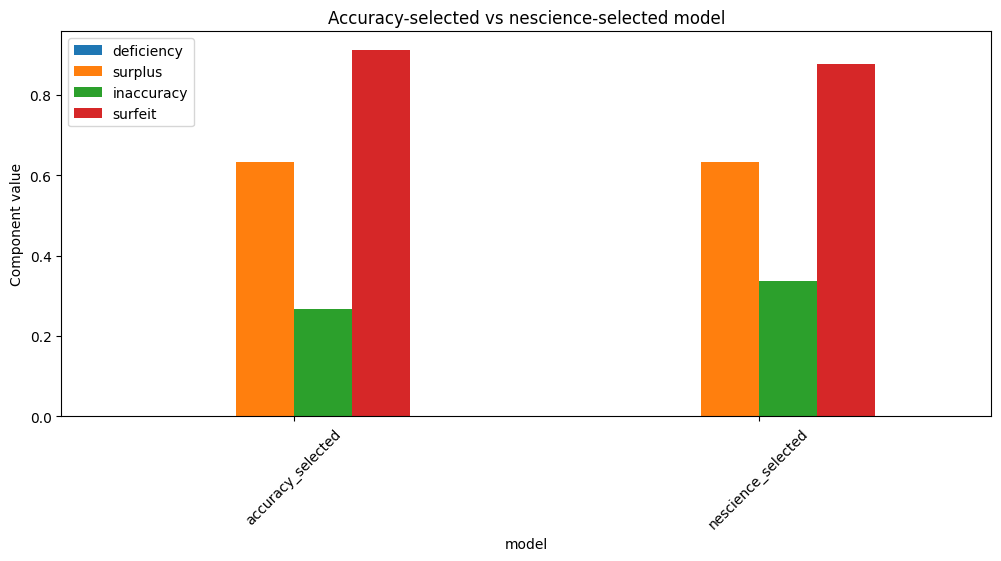

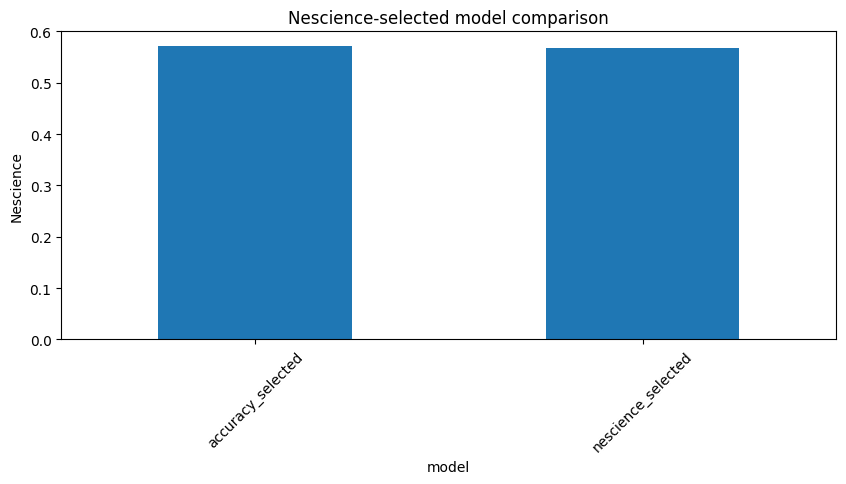

In [28]:
plot_components(search_comparison, "Accuracy-selected vs nescience-selected model")
plot_nescience(search_comparison, "Nescience-selected model comparison")


The nescience-selected model may not maximize accuracy alone. Its purpose is to balance predictive error with input deficiency, input surplus, and model-description surfeit.


## 11. Pareto-style comparison

Because nescience has four components, model comparison does not have to be reduced immediately to a scalar.

A model dominates another model if it is no worse in all four components and strictly better in at least one.


In [29]:
def dominates(row_a, row_b, component_cols):
    """Return True if row_a Pareto-dominates row_b."""
    a = row_a[component_cols].to_numpy(dtype=float)
    b = row_b[component_cols].to_numpy(dtype=float)
    return np.all(a <= b) and np.any(a < b)


component_cols = ["deficiency", "surplus", "inaccuracy", "surfeit"]

candidate_rows = []

for depth in range(1, 12):
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)

    artifacts = model_artifacts(tree, X_test)
    components = nsc_test.components(**artifacts)

    candidate_rows.append(
        {
            "model": f"tree_depth_{depth}",
            "max_depth": depth,
            "accuracy": accuracy_score(y_test, artifacts["predictions"]),
            "nescience": nsc_test.aggregate_components(**components),
            **components,
        }
    )

candidate_df = pd.DataFrame(candidate_rows)

pareto = []
for i, row_i in candidate_df.iterrows():
    dominated = False
    for j, row_j in candidate_df.iterrows():
        if i == j:
            continue
        if dominates(row_j, row_i, component_cols):
            dominated = True
            break
    pareto.append(not dominated)

candidate_df["pareto_efficient"] = pareto
candidate_df


,model,max_depth,accuracy,nescience,deficiency,surplus,inaccuracy,surfeit,pareto_efficient
0,tree_depth_1,1,0.198148,0.739416,0.787857,0.797787,0.883734,0.385714,True
1,tree_depth_2,2,0.324074,0.583231,0.100245,0.637609,0.721741,0.650485,True
2,tree_depth_3,3,0.475926,0.581897,0.008920,0.633606,0.590143,0.777567,True
3,tree_depth_4,4,0.577778,0.575249,0.000000,0.634042,0.471997,0.835975,True
4,tree_depth_5,5,0.724074,0.567064,0.000000,0.634042,0.360529,0.868479,True
5,tree_depth_6,6,0.779630,0.566047,0.000000,0.634042,0.325460,0.879604,True
6,tree_depth_7,7,0.820370,0.566944,0.000000,0.634042,0.295052,0.892545,True
7,tree_depth_8,8,0.829630,0.569983,0.000000,0.634042,0.292789,0.900991,True
8,tree_depth_9,9,0.853704,0.568110,0.000000,0.634042,0.257683,0.906965,True
9,tree_depth_10,10,0.851852,0.569323,0.000000,0.634042,0.261378,0.908948,False


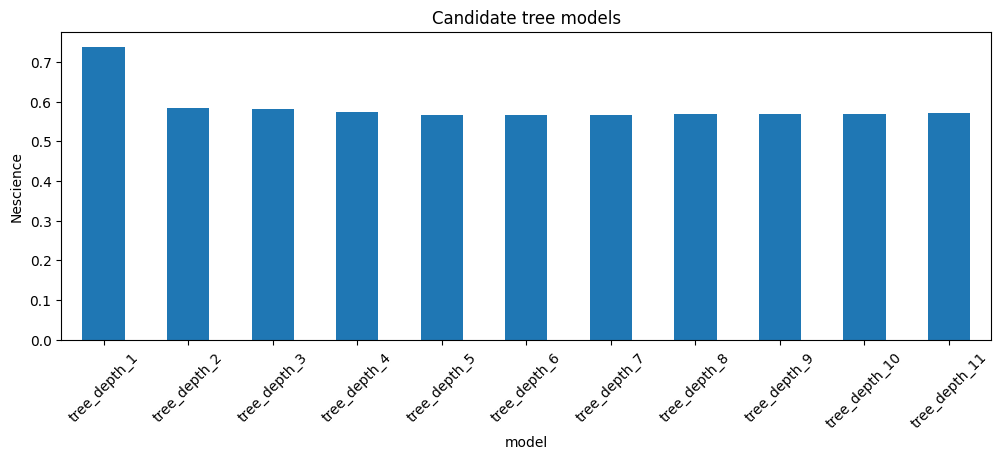

,model,max_depth,accuracy,nescience,deficiency,surplus,inaccuracy,surfeit,pareto_efficient
0,tree_depth_1,1,0.198148,0.739416,0.787857,0.797787,0.883734,0.385714,True
1,tree_depth_2,2,0.324074,0.583231,0.100245,0.637609,0.721741,0.650485,True
2,tree_depth_3,3,0.475926,0.581897,0.008920,0.633606,0.590143,0.777567,True
3,tree_depth_4,4,0.577778,0.575249,0.000000,0.634042,0.471997,0.835975,True
4,tree_depth_5,5,0.724074,0.567064,0.000000,0.634042,0.360529,0.868479,True
5,tree_depth_6,6,0.779630,0.566047,0.000000,0.634042,0.325460,0.879604,True
6,tree_depth_7,7,0.820370,0.566944,0.000000,0.634042,0.295052,0.892545,True
7,tree_depth_8,8,0.829630,0.569983,0.000000,0.634042,0.292789,0.900991,True
8,tree_depth_9,9,0.853704,0.568110,0.000000,0.634042,0.257683,0.906965,True


In [30]:
candidate_df.set_index("model")["nescience"].plot(kind="bar", figsize=(12, 4))
plt.ylabel("Nescience")
plt.title("Candidate tree models")
plt.xticks(rotation=45)
plt.show()

candidate_df[candidate_df["pareto_efficient"]]


The Pareto-efficient models are not dominated component-wise. This is useful when scalar aggregation hides meaningful trade-offs between accuracy, simplicity, surplus, and deficiency.


## 12. Summary

The explicit-input `Nescience` class provides several advantages:

1. It decomposes nescience into four interpretable components.
2. It distinguishes input deficiency from input surplus.
3. It separates prediction inaccuracy from model-description surfeit.
4. It keeps model inspection outside the metric class.
5. It keeps model serialization outside the metric class.
6. It supports diagnostic explanations through `explain(...)`.
7. It supports different aggregation functions and weights.
8. It supports Pareto-style comparison when scalar aggregation is too reductive.

The class is therefore not only a scoring function, but a diagnostic framework for understanding why a model remains partially unknown, inadequate, or excessive.
